<a href="https://colab.research.google.com/github/dante161121/TelecomX_LATAM2.0/blob/main/DesafioLatam_telecom2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exportar los datos**



In [3]:
import pandas as pd
import numpy as np      # ← corregido: np en lugar de n
import requests

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Cargar JSO
df_raw = pd.read_json(url)

print("Columnas de df_raw:")
print(df_raw.columns.tolist())
# ← separar head() en su propia celda para que se muestre correctamente
df_raw.head()
print("\nColumnas dentro de 'customer':")
print(pd.json_normalize(df_raw['customer']).columns.tolist())

print("\nColumnas dentro de 'phone':")
print(pd.json_normalize(df_raw['phone']).columns.tolist())

print("\nColumnas dentro de 'internet':")
print(pd.json_normalize(df_raw['internet']).columns.tolist())

print("\nColumnas dentro de 'account':")
print(pd.json_normalize(df_raw['account']).columns.tolist())

Columnas de df_raw:
['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

Columnas dentro de 'customer':
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']

Columnas dentro de 'phone':
['PhoneService', 'MultipleLines']

Columnas dentro de 'internet':
['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

Columnas dentro de 'account':
['Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


Corregir tipos de datos y construir el DATAFRAME

In [4]:
# Paso 4 – Aplanar columnas anidadas y unir en un solo DataFrame
df_customer  = pd.json_normalize(df_raw['customer'])
df_phone     = pd.json_normalize(df_raw['phone'])
df_internet  = pd.json_normalize(df_raw['internet'])
df_account   = pd.json_normalize(df_raw['account'])

# Añadir customerID y Churn desde el nivel raíz
df_base = df_raw[['customerID', 'Churn']].copy()

# Concatenar todo en un solo df
df = pd.concat([df_base, df_customer, df_phone, df_internet, df_account], axis=1)

print("Shape del DataFrame unificado:", df.shape)
df.head()


Shape del DataFrame unificado: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


ENOMBRAR COLUMNAS

In [5]:
# Paso 5 – Renombrar columnas al español (nombres reales del JSON)
df = df.rename(columns={
    'customerID'       : 'ID_Cliente',
    'gender'           : 'gender',              # se mantiene para compatibilidad
    'SeniorCitizen'    : 'Adulto_Mayor',
    'Partner'          : 'Tiene_Pareja',
    'Dependents'       : 'Tiene_Dependientes',
    'tenure'           : 'Antiguedad_Meses',
    'PhoneService'     : 'Servicio_Telefono',
    'MultipleLines'    : 'MultipleLines',        # se mantiene para compatibilidad
    'InternetService'  : 'InternetService',      # se mantiene para compatibilidad
    'OnlineSecurity'   : 'Seguridad_Online',
    'OnlineBackup'     : 'Respaldo_Online',
    'DeviceProtection' : 'Proteccion_Dispositivo',
    'TechSupport'      : 'Soporte_Tecnico',
    'StreamingTV'      : 'Streaming_TV',
    'StreamingMovies'  : 'Streaming_Peliculas',
    'Contract'         : 'Tipo_Contrato',
    'PaperlessBilling' : 'Factura_Digital',
    'PaymentMethod'    : 'Metodo_Pago',
    'Charges.Monthly'  : 'Cargo_Mensual',        # ← nombre real del JSON
    'Charges.Total'    : 'Cargo_Total',          # ← nombre real del JSON
})

print("Columnas renombradas:")
print(df.columns.tolist())

Columnas renombradas:
['ID_Cliente', 'Churn', 'gender', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Antiguedad_Meses', 'Servicio_Telefono', 'MultipleLines', 'InternetService', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total']


In [6]:
# DIAGNÓSTICO – verificar nombres actuales de columnas
print(df.columns.tolist())

['ID_Cliente', 'Churn', 'gender', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Antiguedad_Meses', 'Servicio_Telefono', 'MultipleLines', 'InternetService', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total']


CORREGIR TIPOS DE DATOS


In [7]:
# Paso 6 – Corregir tipos de datos

# 6.1 – Cargo_Total: puede contener espacios vacíos → convertir a float
df['Cargo_Total'] = pd.to_numeric(df['Cargo_Total'], errors='coerce')

# 6.2 – Churn: convertir Yes/No → 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Tipos de datos corregidos:")
print(df[['Cargo_Total', 'Churn']].dtypes)
print("\nNulos en Cargo_Total:", df['Cargo_Total'].isnull().sum())
print("\nDistribución Churn:\n", df['Churn'].value_counts())



Tipos de datos corregidos:
Cargo_Total    float64
Churn          float64
dtype: object

Nulos en Cargo_Total: 11

Distribución Churn:
 Churn
0.0    5174
1.0    1869
Name: count, dtype: int64


INSPECCION Y LIMPIEZA DE LOS DATOS NULOS Y DUPLICADOS.

In [8]:

# 7.1 – Ver nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 7.2 – Eliminar filas con nulos (los 11 de Cargo_Total)
df = df.dropna()

print("\nDimensiones después de eliminar nulos:", df.shape)

# 7.3 – Verificar duplicados
print("\nRegistros duplicados:", df.duplicated().sum())

# 7.4 – Confirmar que no quedan nulos
print("\nNulos restantes:", df.isnull().sum().sum())

Valores nulos por columna:
Churn          224
Cargo_Total     11
dtype: int64

Dimensiones después de eliminar nulos: (7032, 21)

Registros duplicados: 0

Nulos restantes: 0


In [10]:
print(df.columns.tolist())

['ID_Cliente', 'Churn', 'gender', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Antiguedad_Meses', 'Servicio_Telefono', 'MultipleLines', 'InternetService', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total']


In [11]:
# Guardar DataFrame limpio como CSV
df.to_csv('datos_tratados.csv', index=False)

print("Archivo guardado exitosamente.")
print("Shape final:", df.shape)
print("Columnas:", df.columns.tolist())

Archivo guardado exitosamente.
Shape final: (7032, 21)
Columnas: ['ID_Cliente', 'Churn', 'gender', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Antiguedad_Meses', 'Servicio_Telefono', 'MultipleLines', 'InternetService', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total']


Eliminacion de columnas


In [12]:
df = df.drop(columns=['ID_Cliente'])

In [13]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Churn                   7032 non-null   float64
 1   gender                  7032 non-null   object 
 2   Adulto_Mayor            7032 non-null   int64  
 3   Tiene_Pareja            7032 non-null   object 
 4   Tiene_Dependientes      7032 non-null   object 
 5   Antiguedad_Meses        7032 non-null   int64  
 6   Servicio_Telefono       7032 non-null   object 
 7   MultipleLines           7032 non-null   object 
 8   InternetService         7032 non-null   object 
 9   Seguridad_Online        7032 non-null   object 
 10  Respaldo_Online         7032 non-null   object 
 11  Proteccion_Dispositivo  7032 non-null   object 
 12  Soporte_Tecnico         7032 non-null   object 
 13  Streaming_TV            7032 non-null   object 
 14  Streaming_Peliculas     7032 non-null   objec

,Churn,gender,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Antiguedad_Meses,Servicio_Telefono,MultipleLines,InternetService,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0.0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,1.0,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


Encoding

In [14]:
# Separar variable objetivo
y = df['Churn']
X = df.drop(columns=['Churn'])

# Identificar columnas categóricas
columnas_cat = X.select_dtypes(include=['object']).columns

# One-hot encoding (eliminando la primera categoría para evitar multicolinealidad)
X_encoded = pd.get_dummies(X, columns=columnas_cat, drop_first=True)

# (Opcional) revisar resultado
X_encoded.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Adulto_Mayor                                7032 non-null   int64  
 1   Antiguedad_Meses                            7032 non-null   int64  
 2   Cargo_Mensual                               7032 non-null   float64
 3   Cargo_Total                                 7032 non-null   float64
 4   gender_Male                                 7032 non-null   bool   
 5   Tiene_Pareja_Yes                            7032 non-null   bool   
 6   Tiene_Dependientes_Yes                      7032 non-null   bool   
 7   Servicio_Telefono_Yes                       7032 non-null   bool   
 8   MultipleLines_No phone service              7032 non-null   bool   
 9   MultipleLines_Yes                           7032 non-null   bool   
 10  InternetService_F

In [15]:
df = df.dropna(subset=['Churn'])


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Churn                   7032 non-null   float64
 1   gender                  7032 non-null   object 
 2   Adulto_Mayor            7032 non-null   int64  
 3   Tiene_Pareja            7032 non-null   object 
 4   Tiene_Dependientes      7032 non-null   object 
 5   Antiguedad_Meses        7032 non-null   int64  
 6   Servicio_Telefono       7032 non-null   object 
 7   MultipleLines           7032 non-null   object 
 8   InternetService         7032 non-null   object 
 9   Seguridad_Online        7032 non-null   object 
 10  Respaldo_Online         7032 non-null   object 
 11  Proteccion_Dispositivo  7032 non-null   object 
 12  Soporte_Tecnico         7032 non-null   object 
 13  Streaming_TV            7032 non-null   object 
 14  Streaming_Peliculas     7032 non-null   objec

In [19]:
# Distribución absoluta de Churn
conteo_churn = df['Churn'].value_counts()
print("Conteo de Churn:")
print(conteo_churn)

# Proporción de Churn (relativa)
proporcion_churn = df['Churn'].value_counts(normalize=True)
print("\nProporción de Churn:")
print(proporcion_churn)

# Interpretación rápida
print("\nPorcentaje de clientes que NO cancelaron (Churn=0): {:.2f}%".format(proporcion_churn[0.0] * 100))
print("Porcentaje de clientes que SÍ cancelaron (Churn=1): {:.2f}%".format(proporcion_churn[1.0] * 100))


Conteo de Churn:
Churn
0.0    5163
1.0    1869
Name: count, dtype: int64

Proporción de Churn:
Churn
0.0    0.734215
1.0    0.265785
Name: proportion, dtype: float64

Porcentaje de clientes que NO cancelaron (Churn=0): 73.42%
Porcentaje de clientes que SÍ cancelaron (Churn=1): 26.58%


In [20]:
print("Dimensiones después de eliminar nulos:", df.shape)

Dimensiones después de eliminar nulos: (7032, 20)


Verificar la si existen aun columnas nulos.

In [21]:
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
Churn                     0
gender                    0
Adulto_Mayor              0
Tiene_Pareja              0
Tiene_Dependientes        0
Antiguedad_Meses          0
Servicio_Telefono         0
MultipleLines             0
InternetService           0
Seguridad_Online          0
Respaldo_Online           0
Proteccion_Dispositivo    0
Soporte_Tecnico           0
Streaming_TV              0
Streaming_Peliculas       0
Tipo_Contrato             0
Factura_Digital           0
Metodo_Pago               0
Cargo_Mensual             0
Cargo_Total               0
dtype: int64


In [22]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [23]:
columnas_cat = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=columnas_cat, drop_first=True)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,  # importante: usar X_encoded
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [25]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4922, 30)
X_test: (2110, 30)
y_train: (4922,)
y_test: (2110,)


In [26]:
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [27]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


In [28]:
from imblearn.over_sampling import SMOTE

In [29]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [30]:
print("Antes de SMOTE:")
print(y_train.value_counts())

print("\nDespués de SMOTE:")
print(y_train_res.value_counts())


Antes de SMOTE:
Churn
0.0    3614
1.0    1308
Name: count, dtype: int64

Después de SMOTE:
Churn
1.0    3614
0.0    3614
Name: count, dtype: int64


In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [33]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

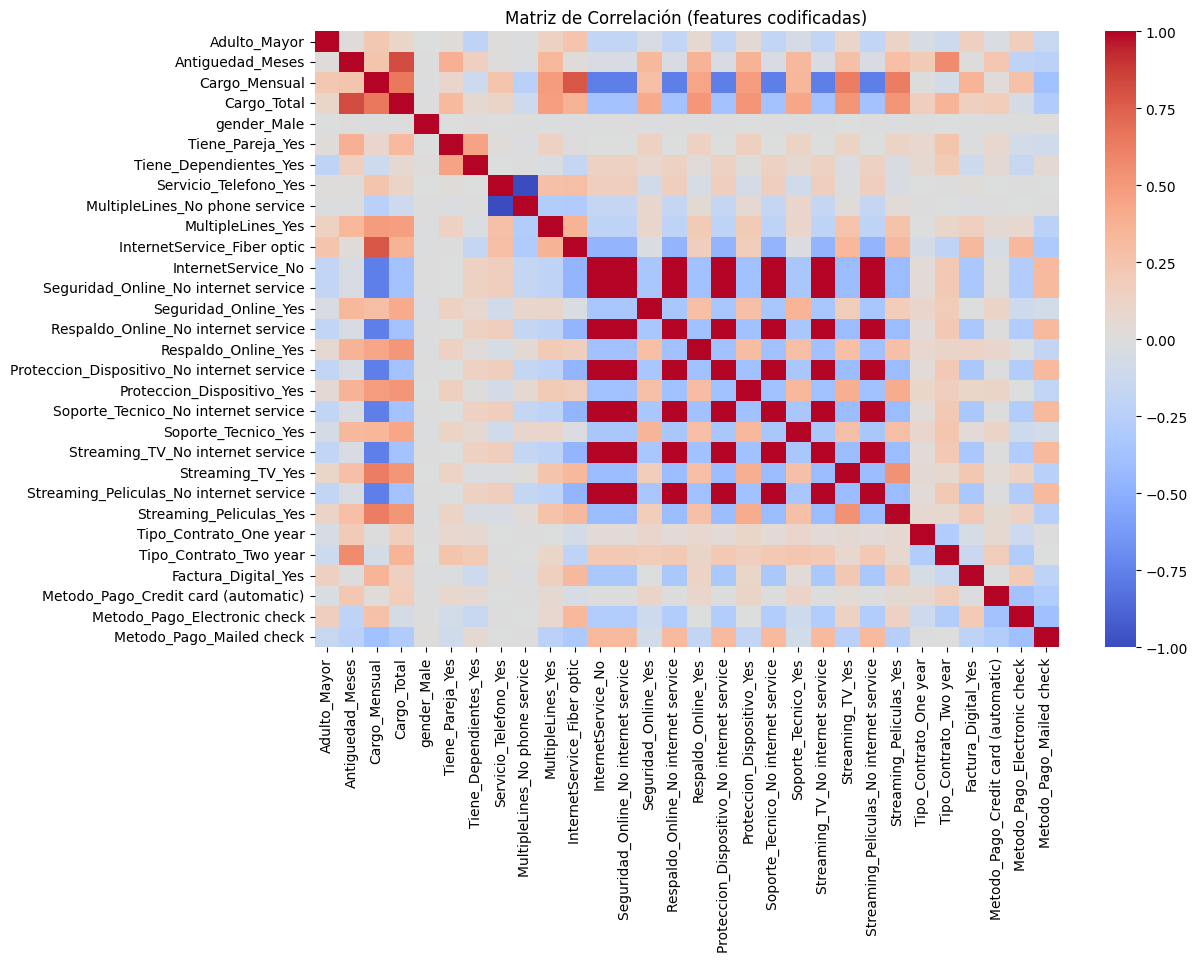

In [36]:
plt.figure(figsize=(12, 8))
correlation = X_encoded.corr()
sns.heatmap(correlation, cmap='coolwarm', annot=False)
plt.title('Matriz de Correlación (features codificadas)')
plt.show()



In [42]:
# Unir X_encoded (todas las features numéricas) con la variable objetivo y
df_corr = X_encoded.join(y)

correlacion_churn = df_corr.corr()['Churn'].sort_values(ascending=False)
correlacion_churn



,Churn
Churn,1.000000
InternetService_Fiber optic,0.307463
Metodo_Pago_Electronic check,0.301455
Cargo_Mensual,0.192858
Factura_Digital_Yes,0.191454
Adulto_Mayor,0.150541
Streaming_TV_Yes,0.063254
Streaming_Peliculas_Yes,0.060860
MultipleLines_Yes,0.040033
Servicio_Telefono_Yes,0.011691


In [43]:
correlacion_churn.head(10)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.307463
Metodo_Pago_Electronic check,0.301455
Cargo_Mensual,0.192858
Factura_Digital_Yes,0.191454
Adulto_Mayor,0.150541
Streaming_TV_Yes,0.063254
Streaming_Peliculas_Yes,0.060860
MultipleLines_Yes,0.040033
Servicio_Telefono_Yes,0.011691


In [44]:
correlacion_churn.tail(10)

,Churn
Cargo_Total,-0.199484
Seguridad_Online_No internet service,-0.227578
Streaming_Peliculas_No internet service,-0.227578
Respaldo_Online_No internet service,-0.227578
InternetService_No,-0.227578
Soporte_Tecnico_No internet service,-0.227578
Proteccion_Dispositivo_No internet service,-0.227578
Streaming_TV_No internet service,-0.227578
Tipo_Contrato_Two year,-0.301552
Antiguedad_Meses,-0.354049


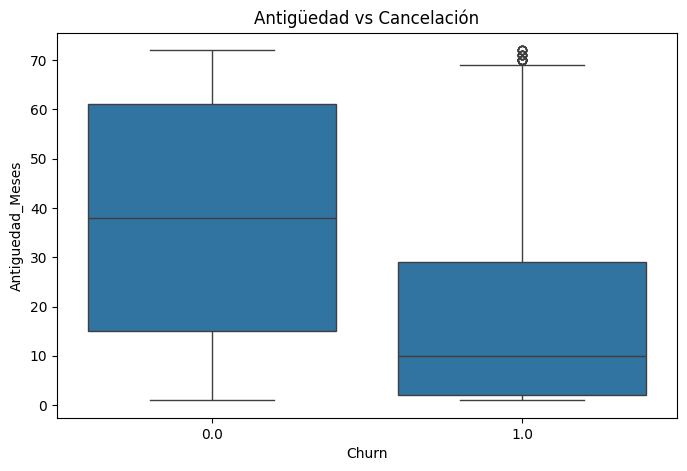

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Antiguedad_Meses', data=df)
plt.title('Antigüedad vs Cancelación')
plt.show()

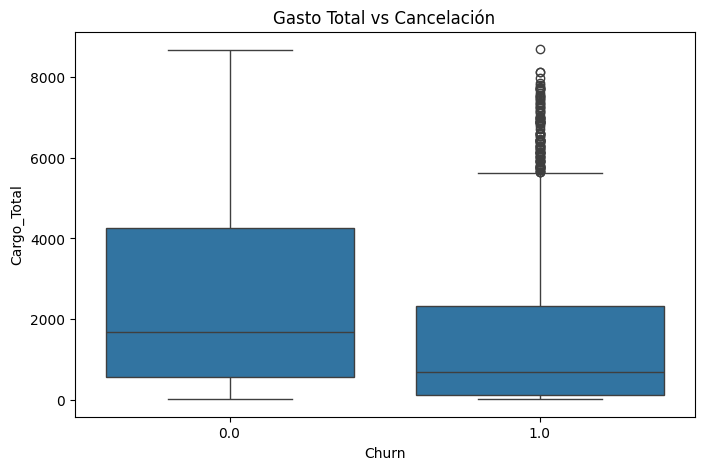

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Cargo_Total', data=df)
plt.title('Gasto Total vs Cancelación')
plt.show()

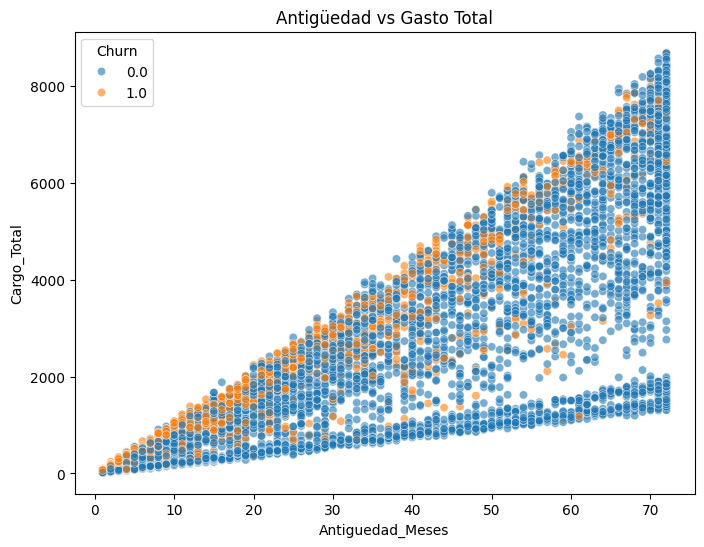

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Antiguedad_Meses',
    y='Cargo_Total',
    hue='Churn',
    data=df,
    alpha=0.6
)
plt.title('Antigüedad vs Gasto Total')
plt.show()

In [49]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [53]:
# Asegúrate de NO redefinir X con df crudo más abajo
# Usa X_encoded (ya numérico) para el split:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Ahora sí, escalar:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4922, 19)
X_test: (2110, 19)
y_train: (4922,)
y_test: (2110,)


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [57]:
y_pred_log = log_model.predict(X_test_scaled)

In [58]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log))

Accuracy Regresión Logística: 0.8033175355450237

Matriz de Confusión:
[[1390  159]
 [ 256  305]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.60       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [60]:
y_pred_rf = rf_model.predict(X_test)

In [61]:
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.7853080568720379

Matriz de Confusión:
[[1385  164]
 [ 289  272]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1549
         1.0       0.62      0.48      0.55       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.77      0.79      0.78      2110



In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("===== REGRESIÓN LOGÍSTICA =====")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log))

===== REGRESIÓN LOGÍSTICA =====
Accuracy: 0.8033175355450237
Precision: 0.6573275862068966
Recall: 0.5436720142602496
F1-score: 0.5951219512195122

Matriz de Confusión:
[[1390  159]
 [ 256  305]]


In [63]:
print("===== RANDOM FOREST =====")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))

===== RANDOM FOREST =====
Accuracy: 0.7853080568720379
Precision: 0.6238532110091743
Recall: 0.48484848484848486
F1-score: 0.5456369107321966

Matriz de Confusión:
[[1385  164]
 [ 289  272]]


In [72]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [73]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("===== KNN =====")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_knn))


===== KNN =====
Accuracy: 0.7578199052132701
Precision: 0.5471698113207547
Recall: 0.5169340463458111
F1-score: 0.5316223648029331

Matriz de Confusión:
[[1309  240]
 [ 271  290]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.83      0.85      0.84      1549
         1.0       0.55      0.52      0.53       561

    accuracy                           0.76      2110
   macro avg       0.69      0.68      0.68      2110
weighted avg       0.75      0.76      0.76      2110



In [74]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("\n===== SVM (RBF) =====")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_svm))


===== SVM (RBF) =====
Accuracy: 0.7971563981042654
Precision: 0.6579572446555819
Recall: 0.49376114081996436
F1-score: 0.5641547861507128

Matriz de Confusión:
[[1405  144]
 [ 284  277]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87      1549
         1.0       0.66      0.49      0.56       561

    accuracy                           0.80      2110
   macro avg       0.74      0.70      0.72      2110
weighted avg       0.79      0.80      0.79      2110



In [64]:
print("Accuracy entrenamiento - Logística:",
      log_model.score(X_train_scaled, y_train))

print("Accuracy prueba - Logística:",
      log_model.score(X_test_scaled, y_test))

print("Accuracy entrenamiento - Random Forest:",
      rf_model.score(X_train, y_train))

print("Accuracy prueba - Random Forest:",
      rf_model.score(X_test, y_test))

Accuracy entrenamiento - Logística: 0.8075985371800082
Accuracy prueba - Logística: 0.8033175355450237
Accuracy entrenamiento - Random Forest: 0.9985778138967899
Accuracy prueba - Random Forest: 0.7853080568720379


In [66]:
import pandas as pd

coeficientes = pd.DataFrame({
    'Variable': X_encoded.columns,
    'Coeficiente': log_model.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)
coeficientes.head(10)


,Variable,Coeficiente
3,Cargo_Total,0.626025
10,InternetService_Fiber optic,0.594341
21,Streaming_TV_Yes,0.201481
28,Metodo_Pago_Electronic check,0.183835
26,Factura_Digital_Yes,0.180289
23,Streaming_Peliculas_Yes,0.156266
9,MultipleLines_Yes,0.129529
0,Adulto_Mayor,0.094955
17,Proteccion_Dispositivo_Yes,0.038262
8,MultipleLines_No phone service,0.019353


In [67]:
coeficientes.tail(10)

,Variable,Coeficiente
18,Soporte_Tecnico_No internet service,-0.071715
12,Seguridad_Online_No internet service,-0.071715
22,Streaming_Peliculas_No internet service,-0.071715
16,Proteccion_Dispositivo_No internet service,-0.071715
13,Seguridad_Online_Yes,-0.096265
19,Soporte_Tecnico_Yes,-0.149677
24,Tipo_Contrato_One year,-0.285491
2,Cargo_Mensual,-0.510416
25,Tipo_Contrato_Two year,-0.542835
1,Antiguedad_Meses,-1.343554


In [69]:
importancia = pd.DataFrame({
    'Variable': X_encoded.columns,
    'Importancia': rf_model.feature_importances_
})

importancia = importancia.sort_values(by='Importancia', ascending=False)
importancia.head(10)


,Variable,Importancia
3,Cargo_Total,0.187292
1,Antiguedad_Meses,0.173152
2,Cargo_Mensual,0.172056
28,Metodo_Pago_Electronic check,0.042456
10,InternetService_Fiber optic,0.037833
4,gender_Male,0.029014
25,Tipo_Contrato_Two year,0.028802
13,Seguridad_Online_Yes,0.026217
26,Factura_Digital_Yes,0.025263
19,Soporte_Tecnico_Yes,0.023652


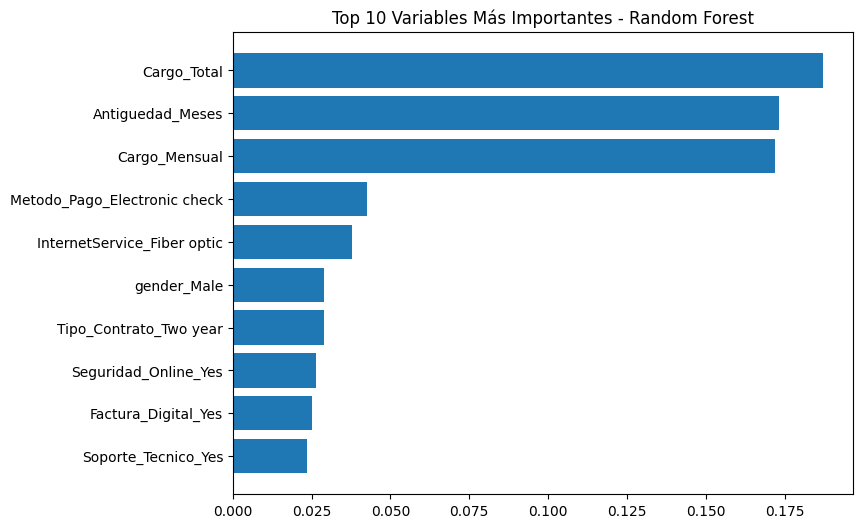

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(importancia['Variable'][:10], importancia['Importancia'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Variables Más Importantes - Random Forest')
plt.show()

In [71]:
coeficientes.head(5)
importancia.head(5)

,Variable,Importancia
3,Cargo_Total,0.187292
1,Antiguedad_Meses,0.173152
2,Cargo_Mensual,0.172056
28,Metodo_Pago_Electronic check,0.042456
10,InternetService_Fiber optic,0.037833


**Analisis de los modelos**

En la evaluación de los modelos para predecir la cancelación de clientes, todos muestran un desempeño aceptable, pero con diferencias claras en estabilidad y capacidad de generalización.

Regresión Logística:
Es el modelo más equilibrado. Mantiene una exactitud cercana a 0.80 tanto en entrenamiento como en prueba, con buena precisión y recall para la clase de cancelación. No presenta señales de sobreajuste ni de bajo ajuste, y su matriz de confusión es estable. En conjunto, es el modelo más confiable y con mejor desempeño global.

KNN y SVM:
Obtienen resultados similares o ligeramente inferiores a la Regresión Logística. Suelen mejorar alguna métrica específica (como recall o precisión), pero a costa de empeorar otra, generando más falsos positivos o falsos negativos. Son modelos útiles como referencia, pero no superan claramente a la Logística en este caso.

Random Forest:
Logra una exactitud casi perfecta en entrenamiento, pero su rendimiento baja notablemente en prueba. Esta gran diferencia indica overfitting: el modelo aprende demasiado los datos de entrenamiento y no generaliza igual de bien. Aunque sigue teniendo métricas aceptables, necesita ajustar su complejidad (profundidad de árboles, número de árboles, muestras por hoja) para mejorar su desempeño en datos nuevos.

El modelo con mejor desempeño general y mayor estabilidad es la Regresión Logística, ya que combina buenas métricas con una brecha mínima entre entrenamiento y prueba. Random Forest y los modelos basados en distancia pueden usarse como complemento, pero requieren ajustes adicionales para optimizar su rendimiento.

**Evaluacion de las variables**

El análisis de los modelos muestra resultados coherentes sobre qué factores influyen más en la cancelación de clientes.

En Regresión Logística, aumentan la probabilidad de churn variables como el alto gasto total, tener internet por fibra óptica, pagar con electronic check, usar factura digital, consumir servicios de streaming, tener múltiples líneas y ser adulto mayor. En cambio, reducen la probabilidad de cancelación la antigüedad del cliente, los contratos a uno o dos años, contar con seguridad online o soporte técnico, y tener pareja o dependientes. En resumen, los clientes con más tiempo en la empresa, contratos largos y servicios de protección tienden a ser más leales.

En Random Forest, las variables más importantes confirman este patrón: el gasto (mensual y total), la antigüedad, el tipo de contrato, el método de pago y el tipo de internet son determinantes clave. También se refuerza que los contratos largos y los servicios de soporte y seguridad actúan como factores protectores.

Aunque KNN y SVM no muestran coeficientes directos, sus resultados respaldan que las mismas dimensiones —antigüedad, nivel de gasto, tipo de contrato, internet y método de pago— son las que más influyen en la decisión del cliente de quedarse o cancelar.

En conjunto, la cancelación se asocia principalmente con clientes nuevos, con contratos mes a mes, fibra óptica, pago electrónico y alto consumo de servicios digitales; mientras que los clientes con mayor permanencia, contratos largos y servicios adicionales presentan un riesgo mucho menor de churn.

**Conclusion**

**Factores clave que influyen en la cancelación**

La cancelación aumenta principalmente en clientes con:

1. Contrato mes a mes.

2. Internet de fibra óptica.

3. Pago mediante Electronic check.

Factura digital.

1. Alto consumo de servicios digitales (streaming, múltiples líneas).

2. Baja antigüedad.

En cambio, el riesgo disminuye en clientes con:

1. Mayor tiempo en la empresa.

2. Contratos de uno o dos años.

3. Servicios de seguridad y soporte.

4. Pareja y dependientes (hogares más estables).

**Segmento de mayor riesgo**

El perfil más propenso a cancelar combina: contrato mensual, fibra óptica, pago con Electronic check, uso intensivo de servicios digitales y poca antigüedad.
Son clientes recientes, sensibles al precio y a la experiencia del servicio.

**Recomendaciones estratégicas**

Incentivar el paso de contratos mensuales a planes de 1–2 años.

Mejorar la experiencia del servicio en fibra óptica.

Promover métodos de pago automáticos con beneficios asociados.

Crear paquetes de valor para usuarios intensivos.

Potenciar los servicios de seguridad y soporte como herramientas de fidelización.

Implementar el modelo de Regresión Logística en el CRM para generar un score de riesgo y priorizar acciones de retención.

La cancelación no es aleatoria, está fuertemente relacionada con tipo de contrato, antigüedad, internet, método de pago y uso de servicios.

La Regresión Logística es el modelo más sólido para producción y permite enfocar estrategias de retención en los clientes de mayor riesgo, especialmente los nuevos, con contrato mensual, fibra óptica y pago electrónico.